### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [25]:
from imblearn.over_sampling import RandomOverSampler
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Load Dataset

In [5]:
dataset = load_breast_cancer()

In [6]:
df = pd.DataFrame(dataset['data'], columns=dataset['feature_names'])
df['target'] = dataset['target']

In [7]:
df.shape

(569, 31)

In [8]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Step 3: Exploaring Data

Basic Info

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [11]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Feature Distribution

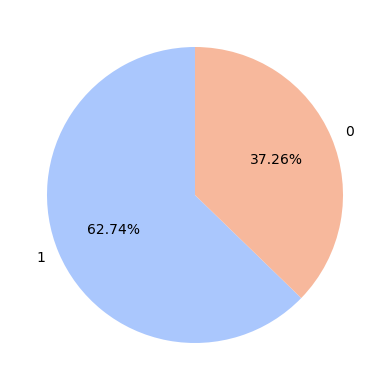

In [12]:
plt.figure(figsize=(4, 4))
plt.pie(
    df['target'].value_counts(),
    autopct='%.2f%%',
    colors=sns.color_palette('coolwarm', 2),
    startangle=90,
    labels=df['target'].value_counts().index
)
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Value

In [13]:
df.dropna(axis=0, ignore_index=False, inplace=True)

Label Encoding

Normalization

In [16]:
num_list = df.select_dtypes(np.number).columns

In [18]:
scaler = StandardScaler()

In [19]:
for col in num_list:
    if col == 'target':
        continue
    df[col] = scaler.fit_transform(df[[col]])

### Step 5: Preparing Data

Select Features

In [251]:
features = df.drop('target', axis=1)
target = df['target']

In [252]:
selector = SmartCorrelatedSelection(
    threshold=0.999,
    selection_method='corr_with_target'
)

In [253]:
features = selector.fit_transform(features, target)
print(f'Current number of features: {features.shape[1]}')

Current number of features: 30


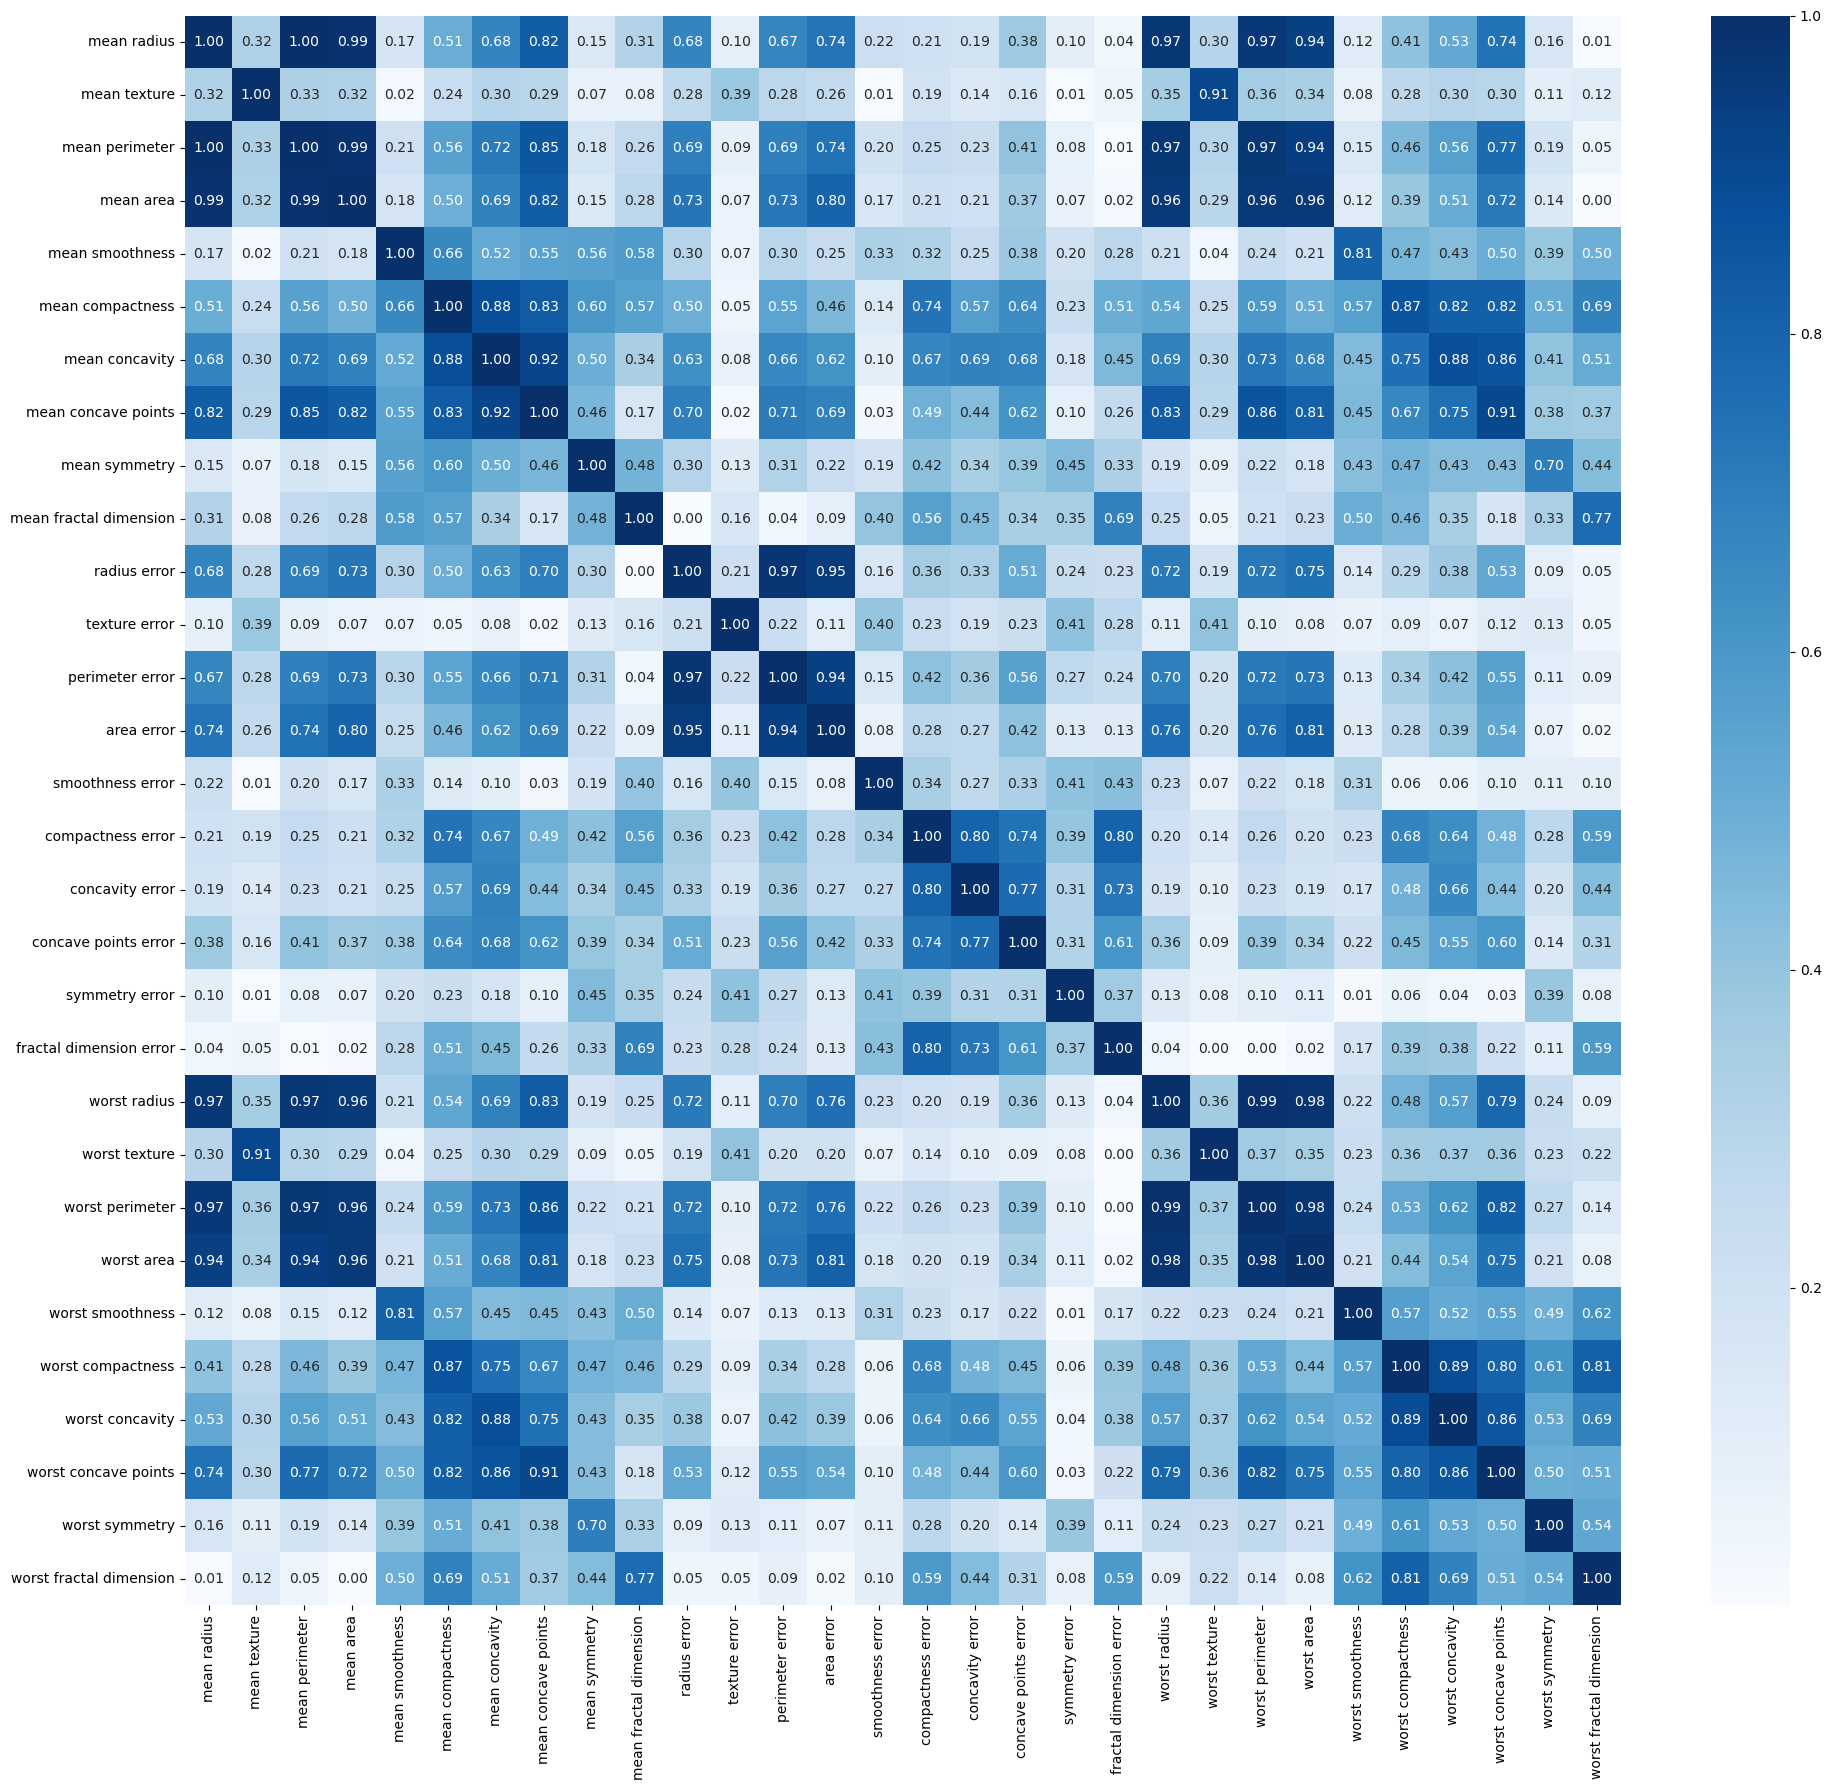

In [254]:
plt.figure(figsize=(20, 18))
sns.heatmap(
    features.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

Split Data

In [229]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

Balanced Data

In [230]:
ros = RandomOverSampler(random_state=42)

In [231]:
X_train, y_train = ros.fit_resample(X_train, y_train)

### Step 6: Building & Training Model

In [232]:
model = GaussianNB()

In [233]:
strat = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [234]:
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=strat,
    scoring='accuracy',
    n_jobs=-1,
    error_score='raise'
)

In [235]:
print(f'Model: {model.__class__.__name__}')
print(f'Scores: {list(map(lambda x: round(x, 3), scores))}')
print(f'Mean Accuracy: {scores.mean():.3f}')

Model: GaussianNB
Scores: [0.93, 0.93, 0.904, 0.904, 0.921]
Mean Accuracy: 0.918


In [236]:
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


### Step 7: Evaluate Model

In [237]:
y_pred = model.predict(X_test)

Accuracy

In [238]:
accuracy = metrics.accuracy_score(y_test, y_pred)

In [239]:
print(f'Accuracy of the model is {100 * accuracy:.3f}%')

Accuracy of the model is 96.491%


In [240]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Confusion Matrix

In [241]:
cm = metrics.confusion_matrix(y_test, y_pred)

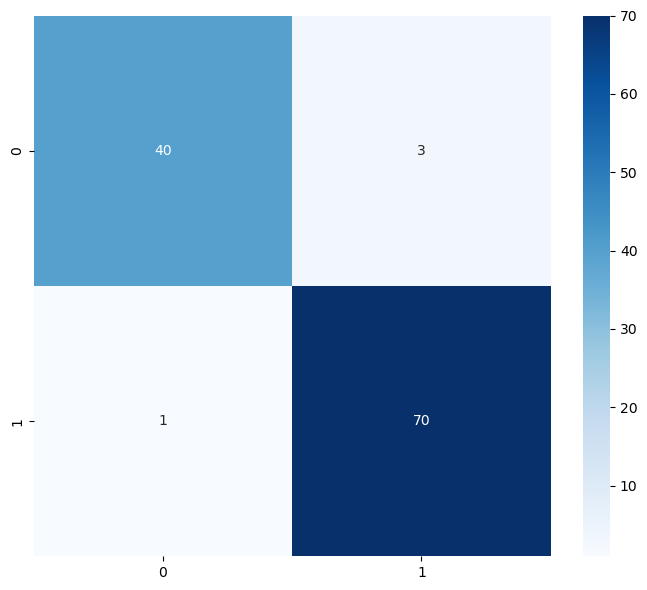

In [242]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()